# OghmaNano Fabry–Pérot FDTD → TMM 对齐验证

Oghma v8.1 FDTD 项目 [`01_hello_fabry_perot`](../../oghma_projects/fabry_perot/01_hello_fabry_perot)：
用 [`00_software_alignment_skills.md`](00_software_alignment_skills.md) 正向构造 `I_new(λ)` 驱动 **emission TMM**（hs 偶极子 @ `z_source`，`u=0`）与 **被动 TMM**，
经 [`oghma_fdtd_alignment.py`](oghma_fdtd_alignment.py) 统一数据读取与 `evaluate_case` 比对。

参考 [`05_bragg_grating.ipynb`](05_bragg_grating.ipynb) Case A/B/C 流程（Fabry 另有 Case D）。

**运行前提**（[README.md](../../../../README.md)）：`build/simulation.so`；venv + `LD_LIBRARY_PATH`。


In [1]:
import numpy as np

from oghma_runtime import bootstrap_tmm_session

REPO, BUILD, TMM_DIR = bootstrap_tmm_session()
import simulation

from oghma_core import _structure_pos_from_layers
from oghma_oled_utils import (
    build_fabry_perot_stack,
    compute_fabry_emission_case_bc_spectra,
    compute_fabry_emission_transfer,
    compute_fabry_lam_e_norm,
    compute_fabry_passive_transfer,
    compute_fabry_reflection_ahead_of_z,
    display_alignment_reports,
    evaluate_case,
    fabry_perot_interface_R_at_wl,
    fabry_perot_stack_labels,
    fabry_perot_thicknesses_um,
    fdtd_input_combine_power,
    integrate_incoherent_power,
    load_fdtd_alignment_bundle,
    parse_fabry_perot_geometry,
    plot_case_summary_grid,
    plot_fabry_perot_fdtd_stack_section,
    plot_forward_source_diagnostic,
    predict_fdtd_output_spectrum_incoherent,
    s_in_times_intensity,
)

bundle = load_fdtd_alignment_bundle(
    REPO,
    "oghma_projects/fabry_perot/01_hello_fabry_perot",
    parse_fabry_perot_geometry,
)
MASK_FULL = (bundle.wl_um >= 0.4) & (bundle.wl_um <= 0.6)
MASK_RES = (bundle.wl_um >= 0.48) & (bundle.wl_um <= 0.52)

print(f"BUILD={BUILD}")
print(f"cavity L={bundle.geom.cavity_length_um * 1e3} nm, mirror={bundle.geom.mirror_thickness_um * 1e3} nm")
print(f"λ₁=2nL≈{bundle.geom.fundamental_resonance_um * 1e3:.0f} nm")
print(f"z_source={bundle.layout.z_source_um * 1e3:.0f} nm, z_det_in={bundle.layout.z_detector_in_um * 1e3:.0f} nm")
print(f"λ: {bundle.wl_um[0]*1e3:.0f}–{bundle.wl_um[-1]*1e3:.0f} nm ({len(bundle.wl_um)} pts)")
print(f"FDTD source: {bundle.fdtd_src.waveform}, Ey={bundle.fdtd_src.excite_ey}")
print(f"emission dipole: orient=hs, u=0, z={bundle.layout.z_source_um * 1e3:.0f} nm")


BUILD=/home/like/repos/simulation/build
materials: /mnt/c/Users/like/oghma_local/materials
cavity L=250.0 nm, mirror=10.0 nm
λ₁=2nL≈500 nm
z_source=19 nm, z_det_in=240 nm
λ: 205–1195 nm (100 pts)
FDTD source: gaus_sin, Ey=True
emission dipole: orient=hs, u=0, z=19 nm


## §1 器件堆栈

物理 FDTD 膜系；两侧半无限 air 对应 PML。


TMM 界面 z (nm): [       -inf 0.00000e+00 1.00000e+01 2.60000e+02 2.70000e+02 1.00027e+06]
有限层总厚: 270.0 nm
TMM R @ 500 nm (air|mirror slab): 0.194


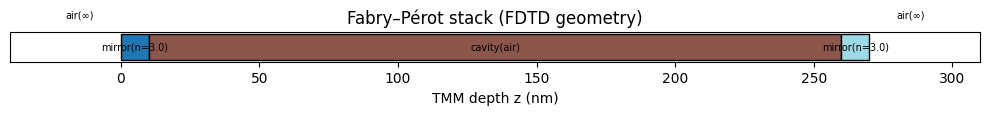

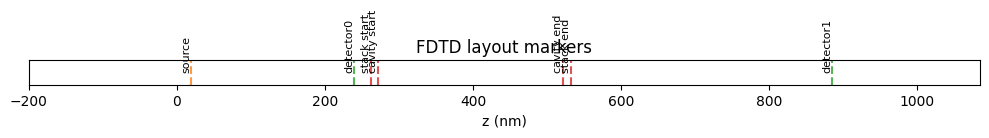

In [ ]:
layers_demo = build_fabry_perot_stack(
    bundle.geom, 500.0, simulation
)
pos = _structure_pos_from_layers(layers_demo)
labels = fabry_perot_stack_labels(bundle.geom)
thicknesses_nm = fabry_perot_thicknesses_um(bundle.geom)
print("TMM 界面 z (nm):", np.round(pos, 2))
print(f"有限层总厚: {bundle.geom.total_film_thickness_um * 1e3} nm")
R500 = fabry_perot_interface_R_at_wl(
    bundle.geom, 500.0, simulation
)
print(f"TMM R @ 500 nm (air|mirror slab): {R500:.3f}")
plot_fabry_perot_fdtd_stack_section(
    bundle.geom,
    bundle.layout,
    simulation,
)


## §2 等效光源（消除时间项）

预期：`S_in ≈ I_new × G_in`；全部经 `evaluate_case` 比对。


In [3]:
r_det = compute_fabry_reflection_ahead_of_z(
    bundle.layout.z_detector_in_um * 1e3,
    bundle.geom,
    bundle.layout,
    bundle.wl_um,
    simulation,
    )
g_in = fdtd_input_combine_power(r_det)
s_pred_det0 = predict_fdtd_output_spectrum_incoherent(bundle.i_new, g_in)
s_in_norm = s_in_times_intensity(bundle)

evaluate_case(
    bundle,
    "§2 I_new vs S_IN×Intensity",
    bundle.i_new,
    s_in_norm,
    mask=MASK_FULL,
    mask_label="400,600",
    ylabel="|E|²",
    title="§2: I_new vs S_IN×Intensity",
    tmm_label="I_new",
    baseline_name="S_IN×Int",
    use_stop_band=False,
)
evaluate_case(
    bundle,
    "§2 I_new×G_in vs S_IN",
    s_pred_det0,
    bundle.s_in,
    mask=MASK_FULL,
    mask_label="400,600",
    ylabel="|E|²",
    title="§2: I_new×G_in vs detector0",
    tmm_label="I_new×G_in(ignore temporal coherence)",
    baseline_name="S_IN (det0)",
    use_stop_band=False,
)
# plot_forward_source_diagnostic(bundle, g_in, s_pred_det0, s_in_norm=s_in_norm)


[FAIL] §2 I_new vs S_IN×Intensity (raw): RMSE=0.1181, max|err|=0.4841, corr=0.9371
[FAIL] §2 I_new vs S_IN×Intensity (raw) [400,600]: RMSE=0.2531, max|err|=0.4841, corr=0.9397
[PASS (envelope)] §2 I_new vs S_IN×Intensity (norm): norm-corr=0.9371, RMSE=0.0803
[PASS (envelope)] §2 I_new vs S_IN×Intensity norm [400,600]: norm-corr=0.9397, RMSE=0.1769
[FAIL] §2 I_new×G_in vs S_IN (raw): RMSE=0.2231, max|err|=0.9991, corr=0.8639
[FAIL] §2 I_new×G_in vs S_IN (raw) [400,600]: RMSE=0.4498, max|err|=0.9991, corr=0.9237
[PASS (envelope)] §2 I_new×G_in vs S_IN (norm): norm-corr=0.8639, RMSE=0.1057
[PASS (envelope)] §2 I_new×G_in vs S_IN norm [400,600]: norm-corr=0.9237, RMSE=0.1963


## §3 Case A — 传递比 T(λ)

$T/|1+r|^2$：emission TMM vs 被动 TMM。


In [4]:
em = compute_fabry_emission_transfer(
    bundle.geom,
    bundle.layout,
    bundle.wl_um,
    simulation,
    z_um=bundle.layout.z_source_um,
    u=0.0,
    orient="hs",
)
t_em = em["t_trans_ratio_fdtd"]
t_passive = compute_fabry_lam_e_norm(
    bundle.geom,
    bundle.layout,
    bundle.wl_um,
    simulation,
    )

evaluate_case(
    bundle,
    "Case A T_em",
    t_em,
    t_passive,
    ylabel="T/G_in",
    title="Case A: emission T/G_in vs passive T/G_in",
    tmm_label="T(emission)/|1+r|^2",
    baseline_name="T/|1+r|^2",
)
# evaluate_case(
#     bundle,
#     "Case A [480,520]",
#     t_em[MASK_RES],
#     t_passive[MASK_RES],
#     bundle.wl_um[MASK_RES],
#     ylabel="T/G_in",
#     title="Case A resonance window",
#     tmm_label="T(emission)/|1+r|^2",
#     baseline_name="T/|1+r|^2",
# )


[FAIL] Case A T_em (raw): RMSE=0.5722, max|err|=0.8926, corr=-0.1615
  stop-band λ: ours=315.0 nm, baseline=205.0 nm, Δ=110.0 nm
[FAIL (envelope)] Case A T_em (norm): norm-corr=-0.1615, RMSE=0.5591


## §4 Case B / C / D — 出射监视器能量 vs `detector1/lam_E`

- **Case B**：相干 `flux(E_bot)`，源谱 `I_new`
- **Case C**：`T_passive·I_new`（被动非相干）
- **Case D**：Case B vs Case C（emission vs 被动）


In [5]:
t_passive_t = compute_fabry_passive_transfer(
    bundle.geom,
    bundle.layout,
    bundle.wl_um,
    simulation,
    )
case_bc = compute_fabry_emission_case_bc_spectra(
    simulation,
    bundle.geom,
    bundle.layout,
    bundle.wl_um,
    bundle.s_in,
    spectrum=bundle.i_new,
    t_passive=t_passive_t,
)
s_pred_b = case_bc["s_pred_b"]
s_pred_c = case_bc["s_pred_c"]

evaluate_case(
    bundle,
    "Case B P_bot",
    s_pred_b,
    bundle.s_out,
    ylabel="|E|²",
    title="Case B: coherent flux(E_bot) vs S_OUT",
    tmm_label="flux(E_bot)",
    baseline_name="S_OUT",
)
evaluate_case(
    bundle,
    "Case C T_passive·I_new",
    s_pred_c,
    bundle.s_out,
    ylabel="|E|²",
    title="Case C: T_passive·I_new vs S_OUT",
    tmm_label="T_passive·I_new",
    baseline_name="S_OUT",
)
evaluate_case(
    bundle,
    "Case D emission vs passive",
    s_pred_b,
    s_pred_c,
    ylabel="|E|²",
    title="Case D: emission vs passive",
    tmm_label="Case B",
    baseline_name="Case C",
)

print(f"W_B = ∫ Case B dλ = {integrate_incoherent_power(bundle.wl_um, s_pred_b):.4e}")
print(f"W_C = ∫ Case C dλ = {integrate_incoherent_power(bundle.wl_um, s_pred_c):.4e}")
print(f"W_FDTD = ∫ detector1 lam_E dλ = {integrate_incoherent_power(bundle.wl_um, bundle.s_out):.4e}")


[FAIL] Case B P_bot (raw): RMSE=0.1477, max|err|=0.5918, corr=0.9136
  stop-band λ: ours=205.0 nm, baseline=205.0 nm, Δ=0.0 nm
[PASS (envelope)] Case B P_bot (norm): norm-corr=0.9136, RMSE=0.0944
[FAIL] Case C T_passive·I_new (raw): RMSE=0.1940, max|err|=0.9642, corr=0.9597
  stop-band λ: ours=205.0 nm, baseline=205.0 nm, Δ=0.0 nm
[PASS (envelope)] Case C T_passive·I_new (norm): norm-corr=0.9597, RMSE=0.0602
[FAIL] Case D emission vs passive (raw): RMSE=0.0619, max|err|=0.3911, corr=0.9663
  stop-band λ: ours=205.0 nm, baseline=205.0 nm, Δ=0.0 nm
[PASS (envelope)] Case D emission vs passive (norm): norm-corr=0.9663, RMSE=0.0725
W_B = ∫ Case B dλ = 5.6445e+01
W_C = ∫ Case C dλ = 7.0842e+01
W_FDTD = ∫ detector1 lam_E dλ = 7.2328e-02


## §5 Case 汇总


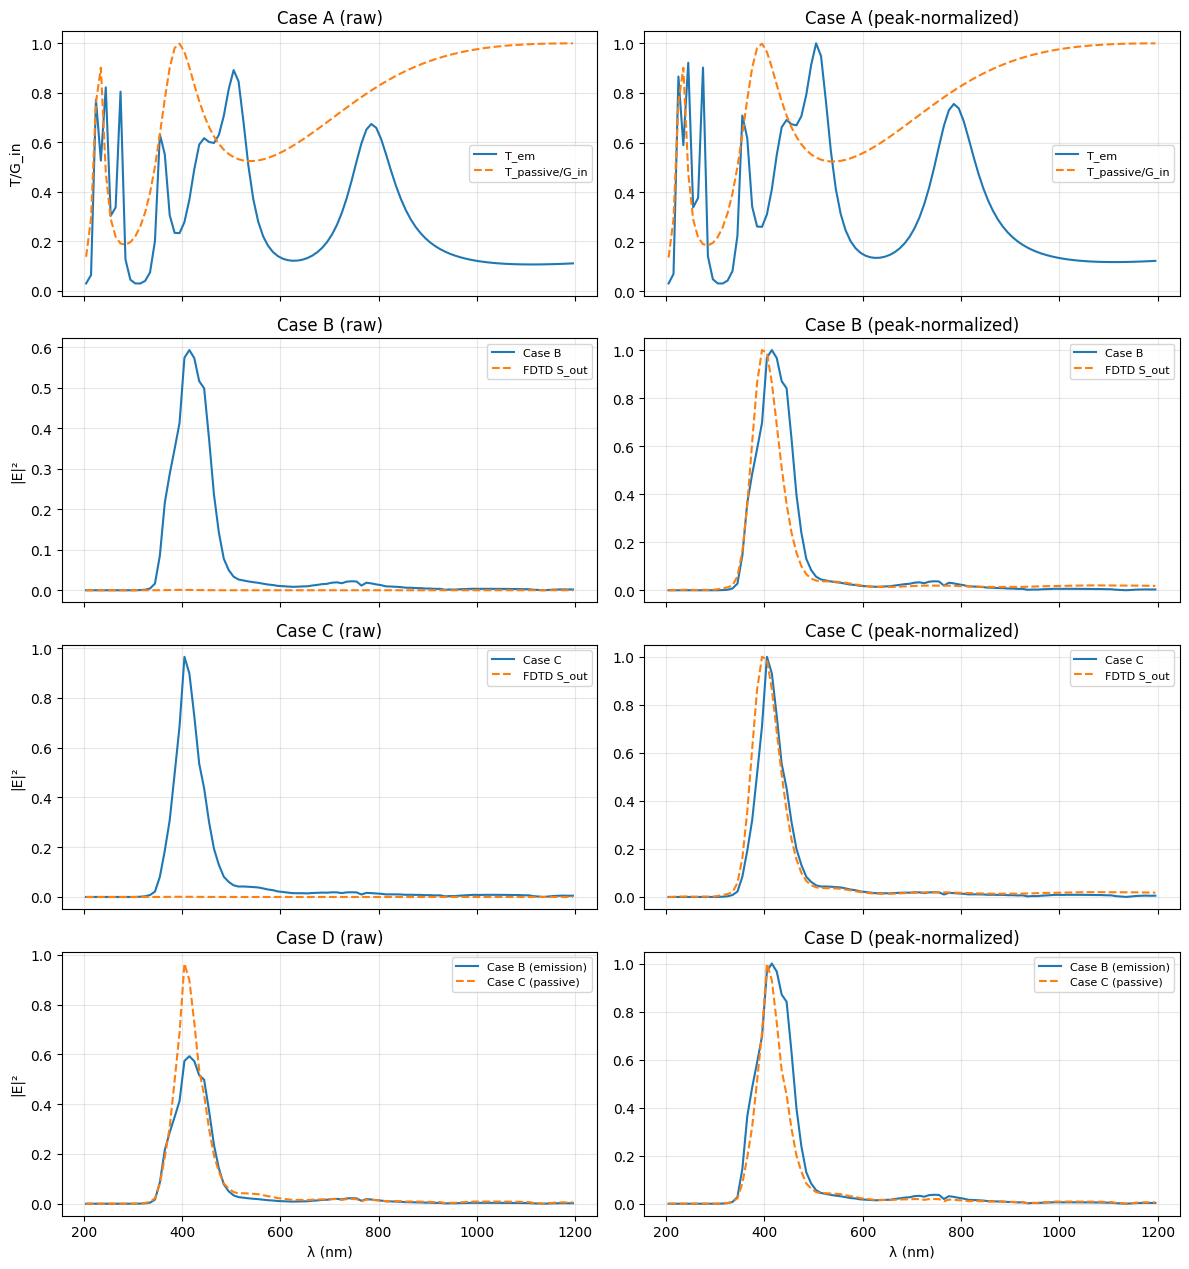

,corr,rmse,norm_corr,rmse_norm,log_domain
case,,,,,
§2 I_new vs S_IN×Intensity,0.937079,0.118111,0.937079,0.080316,False
§2 I_new×G_in vs S_IN,0.863877,0.223101,0.863877,0.105739,False
Case A T_em,-0.161465,0.572192,-0.161465,0.559120,False
Case B P_bot,0.913589,0.147655,0.913589,0.094414,False
Case C T_passive·I_new,0.959716,0.194048,0.959716,0.060219,False
Case D emission vs passive,0.966322,0.061862,0.966322,0.072458,False


,case,rmse,mae,max_abs,corr,status,stop_x_ours,stop_x_baseline,stop_delta_nm,stop_log_rmse
0,§2 I_new vs S_IN×Intensity (raw),0.118111,0.048877,0.484115,0.937079,FAIL,NaN,NaN,NaN,NaN
1,"§2 I_new vs S_IN×Intensity (raw) [400,600]",0.253086,0.192281,0.484115,0.939670,FAIL,NaN,NaN,NaN,NaN
2,§2 I_new vs S_IN×Intensity (norm),0.080316,0.032560,0.382760,0.937079,PASS (envelope),205.0,205.0,0.0,0.465923
3,"§2 I_new vs S_IN×Intensity norm [400,600]",0.176898,0.134308,0.382760,0.939670,PASS (envelope),595.0,515.0,80.0,0.743062
4,§2 I_new×G_in vs S_IN (raw),0.223101,0.088523,0.999061,0.863877,FAIL,NaN,NaN,NaN,NaN
5,"§2 I_new×G_in vs S_IN (raw) [400,600]",0.449771,0.304961,0.999061,0.923708,FAIL,NaN,NaN,NaN,NaN
6,§2 I_new×G_in vs S_IN (norm),0.105739,0.047051,0.442293,0.863877,PASS (envelope),205.0,215.0,10.0,8.234973
7,"§2 I_new×G_in vs S_IN norm [400,600]",0.196344,0.147986,0.432375,0.923708,PASS (envelope),595.0,505.0,90.0,0.859689
8,Case A T_em (raw),0.572192,0.491870,0.892553,-0.161465,FAIL,315.0,205.0,110.0,NaN
9,Case A T_em (norm),0.559120,0.477863,0.879633,-0.161465,FAIL (envelope),315.0,205.0,110.0,NaN


In [6]:
plot_case_summary_grid(
    bundle,
    [
        {
            "title": "Case A",
            "pred": t_em,
            "baseline": t_passive,
            "pred_label": "T_em",
            "baseline_label": "T_passive/G_in",
            "ylabel": "T/G_in",
        },
        {
            "title": "Case B",
            "pred": s_pred_b,
            "baseline": bundle.s_out,
            "pred_label": "Case B",
            "baseline_label": "FDTD S_out",
        },
        {
            "title": "Case C",
            "pred": s_pred_c,
            "baseline": bundle.s_out,
            "pred_label": "Case C",
            "baseline_label": "FDTD S_out",
        },
        {
            "title": "Case D",
            "pred": s_pred_b,
            "baseline": s_pred_c,
            "pred_label": "Case B (emission)",
            "baseline_label": "Case C (passive)",
        },
    ],
)
display_alignment_reports(bundle)
